In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv


In [2]:
df1 = pd.read_csv("/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv")

In [3]:
df = df1.copy()

# ❤️ Heart Disease Dataset - Feature Description

This dataset contains patient medical information used to predict the presence of heart disease.

| Column | Description | Data Type | Values / Units |
|--------|-------------|-----------|----------------|
| **age** | Age of the patient | Numerical | Years |
| **sex** | Gender of the patient | Categorical | 1 = Male, 0 = Female |
| **cp** | Chest Pain Type | Categorical | 0 = Typical Angina<br>1 = Atypical Angina<br>2 = Non-anginal Pain<br>3 = Asymptomatic |
| **trestbps** | Resting Blood Pressure | Numerical | mm Hg |
| **chol** | Serum Cholesterol | Numerical | mg/dL |
| **fbs** | Fasting Blood Sugar | Categorical | 1 = >120 mg/dL<br>0 = ≤120 mg/dL |
| **restecg** | Resting Electrocardiographic Results | Categorical | 0 = Normal<br>1 = ST-T Wave Abnormality<br>2 = Left Ventricular Hypertrophy |
| **thalach** | Maximum Heart Rate Achieved | Numerical | Beats per Minute (bpm) |
| **exang** | Exercise-Induced Angina | Categorical | 1 = Yes<br>0 = No |
| **oldpeak** | ST Depression induced by exercise relative to rest | Numerical | Float |
| **slope** | Slope of the Peak Exercise ST Segment | Categorical | 0 = Upsloping<br>1 = Flat<br>2 = Downsloping |
| **ca** | Number of Major Vessels Colored by Fluoroscopy | Categorical | Integer (0–4) |
| **thal** | Thalassemia Test Result | Categorical | 1 = Normal<br>2 = Fixed Defect<br>3 = Reversible Defect |
| **target** | Presence of Heart Disease | Target Variable | 1 = Heart Disease Present<br>0 = No Heart Disease |

---

# 📌 Feature Categories

## 🔢 Numerical Features

- `age`
- `trestbps`
- `chol`
- `thalach`
- `oldpeak`

---

## 🏷️ Categorical Features

- `sex`
- `cp`
- `fbs`
- `restecg`
- `exang`
- `slope`
- `ca`
- `thal`

---

## 🎯 Target Variable

| Value | Meaning |
|-------|---------|
| **0** | No Heart Disease |
| **1** | Heart Disease Present |

---

# 📖 Medical Terminology

- **Angina:** Chest pain caused by reduced blood flow to the heart.
- **ECG (Electrocardiogram):** A test that records the electrical activity of the heart.
- **ST Depression:** A change observed in an ECG that may indicate reduced blood flow to the heart.
- **Thalassemia:** A blood disorder. In this dataset, the **thal** feature represents the result of a thallium stress test used to evaluate blood flow to the heart.
- **Fluoroscopy:** An imaging technique used to visualize the major blood vessels supplying the heart.

---

# 📊 Dataset Summary

- **Problem Type:** Binary Classification
- **Domain:** Healthcare / Medical Diagnosis
- **Input Features:** 13
- **Target Feature:** `target`
- **Goal:** Predict whether a patient is likely to have heart disease based on clinical measurements and diagnostic test results.

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(723)

In [7]:
df.shape

(1025, 14)

In [8]:
df[df.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
43,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
55,55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
61,66,0,2,146,278,0,0,152,0,0.0,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [9]:
df.drop_duplicates(inplace = True)

In [10]:
df.shape

(302, 14)

In [11]:
import matplotlib.pyplot as plt

(array([ 1., 10., 33., 38., 37., 60., 63., 43., 14.,  3.]),
 array([29. , 33.8, 38.6, 43.4, 48.2, 53. , 57.8, 62.6, 67.4, 72.2, 77. ]),
 <BarContainer object of 10 artists>)

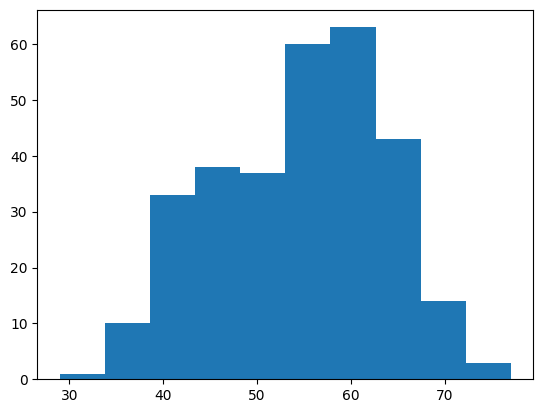

In [12]:
plt.hist(df["age"])